In [65]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import os

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


import math
import matplotlib.pyplot as plt
import numpy as np

from torch.cuda.amp import autocast, GradScaler

In [66]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [67]:

class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed (non-learnable) sinusoidal positional encoding."""
    def __init__(self, num_patches: int, embed_dim: int):
        super().__init__()
        pe = torch.zeros(num_patches, embed_dim)                          
        position  = torch.arange(0, num_patches, dtype=torch.float).unsqueeze(1)  
        div_term  = torch.exp(
            torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim)
        )                                                                  
        pe[:, 0::2] = torch.sin(position * div_term)   
        pe[:, 1::2] = torch.cos(position * div_term)   
        self.register_buffer('pe', pe.unsqueeze(0))    

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]  


In [68]:

DATA_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200"

IMAGE_SIZE = 224
BATCH_SIZE = 64  
transform_basic = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])



train_dataset = torchvision.datasets.ImageFolder(root=os.path.join(DATA_DIR, "train"), transform=transform_basic)


val_dataset = torchvision.datasets.ImageFolder(root=os.path.join(DATA_DIR, "val"), transform=transform_basic)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")


Training samples: 100000, Validation samples: 10000


## Converting Image into 16×16 Patches

We split a 224×224 image into non-overlapping 16×16 patches.  
Each patch is flattened and projected into a vector of dimension `768`  

- Input: `[B, 3, 224, 224]`  
- Output: `[B, N_patches, embed_dim]` where `N_patches = (224/16)^2 = 196`

In [69]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Linear(patch_size * patch_size * in_channels, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        h = H // p
        w = W // p
        x = x.view(B, C, h, p, w, p)
        x = x.permute(0,2,4,3,5,1)   # [B, h, w, p, p, C]
        x = x.reshape(B, h*w, p*p*C) 
        x = self.proj(x)
        return x

# Sample Patch Embedding Dimension
dummy_img = torch.randn(2, 3, 224, 224).to(device)  
patch_layer = PatchEmbedding().to(device)           
patches = patch_layer(dummy_img)

print(f"Input image shape: {dummy_img.shape}")
print(f"Output patches shape: {patches.shape}")
print(f"Device: {patches.device}")                 

Input image shape: torch.Size([2, 3, 224, 224])
Output patches shape: torch.Size([2, 196, 768])
Device: cuda:0


## Random Masking (75%)

To perform self-supervised learning, i masked 75% of patches randomly.  
Only 25% of patches are visible to the encoder.  

- `mask`: binary tensor where `1 = masked`, `0 = visible`  
- `ids_restore`: order to restore patches for the decoder

In [70]:
def random_masking(x, mask_ratio=0.75):
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))

    noise = torch.rand(B, N,device=x.device)
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :len_keep]
    ids_keep = ids_keep.to(x.device)
    ids_restore = ids_restore.to(x.device)
    x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1,1,D))
    mask = torch.ones([B, N],device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)
    return x_masked, mask, ids_restore

#Sample Masking
x_masked, mask, ids_restore = random_masking(patches)

print(f"Visible patches shape: {x_masked.shape}")  
print(f"Mask shape: {mask.shape}")                
print(f"Masked patches count (per sample): {mask.sum(dim=1)}")  


Visible patches shape: torch.Size([2, 49, 768])
Mask shape: torch.Size([2, 196])
Masked patches count (per sample): tensor([147., 147.], device='cuda:0')


# Encoder Architecture

In [71]:
class MAEEncoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, embed_dim=768, num_layers=12, num_heads=12):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, embed_dim=embed_dim)
        n_patches = (img_size // patch_size) ** 2

        self.pos_enc = SinusoidalPositionalEncoding(n_patches, embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x, mask_ratio=0.75):
        x = self.patch_embed(x)          # [B, N, D]
        x = self.pos_enc(x)              
        x_masked, mask, ids_restore = random_masking(x, mask_ratio)
        x_enc = self.encoder(x_masked)
        return x_enc, mask, ids_restore, x_masked


# Decoder Architecture

In [72]:
class MAEDecoder(nn.Module):
    def __init__(self, n_patches, patch_size=16, enc_dim=768, dec_dim=384, num_layers=12, num_heads=6):
        super().__init__()
        self.n_patches   = n_patches
        self.patch_size  = patch_size
        self.mask_token  = nn.Parameter(torch.zeros(1, 1, dec_dim))
        self.decoder_embed = nn.Linear(enc_dim, dec_dim)

        self.pos_enc = SinusoidalPositionalEncoding(n_patches, dec_dim)

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=dec_dim, nhead=num_heads,
            dim_feedforward=dec_dim * 4, batch_first=True
        )
        self.decoder      = nn.TransformerEncoder(decoder_layer, num_layers=num_layers)
        self.decoder_pred = nn.Linear(dec_dim, patch_size * patch_size * 3)

        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def forward(self, x_enc, ids_restore):
        B   = x_enc.size(0)
        x   = self.decoder_embed(x_enc)

        mask_tokens = self.mask_token.expand(B, self.n_patches - x.size(1), -1)
        x_ = torch.cat([x, mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).expand_as(x_))

        x_ = self.pos_enc(x_)

        x_ = self.decoder(x_)
        x_ = self.decoder_pred(x_)
        return x_


# MAE Model

In [73]:
class MAE(nn.Module):
    def __init__(self, img_size=224, patch_size=16,
                 enc_dim=768, dec_dim=384,
                 enc_layers=12, dec_layers=12,
                 enc_heads=12, dec_heads=6, mask_ratio=0.75):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, embed_dim=enc_dim)
        self.n_patches = (img_size // patch_size) ** 2
        self.mask_ratio = mask_ratio

        self.encoder = MAEEncoder(img_size, patch_size, enc_dim, enc_layers, enc_heads)
        self.decoder = MAEDecoder(self.n_patches, patch_size, enc_dim, dec_dim, dec_layers, dec_heads)

    def forward(self, x):
        x_enc, mask, ids_restore, _ = self.encoder(x, mask_ratio=self.mask_ratio)
        x_rec = self.decoder(x_enc, ids_restore)
        return x_rec, mask

# Loss Funtion

In [74]:
def patchify(imgs, patch_size=16):
    B, C, H, W = imgs.shape
    h = w = H // patch_size
    x = imgs.reshape(B, C, h, patch_size, w, patch_size)
    x = x.permute(0, 2, 4, 3, 5, 1)  
    x = x.reshape(B, h * w, patch_size * patch_size * C)
    
    return x


def unpatchify(patches, patch_size=16, img_size=224):
    B, N, D = patches.shape
    h = w = img_size // patch_size
    
    x = patches.reshape(B, h, w, patch_size, patch_size, 3)
    x = x.permute(0, 5, 1, 3, 2, 4)
    imgs = x.reshape(B, 3, h * patch_size, w * patch_size)
    
    return imgs


def mae_loss(pred, target, mask):
    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1)  
    loss = (loss * mask).sum() / mask.sum()
    
    return loss

# Trainning and validation

In [75]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

def build_param_groups(model, weight_decay=0.05):
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim == 1 or 'bias' in name or 'norm' in name.lower() or 'mask_token' in name:
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {"params": decay,    "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]

EPOCHS        = 20
WD            = 0.05
MAX_GRAD_NORM = 1.0
PATCH_SIZE    = 16

PATIENCE = 3
patience_counter = 0

base_model = MAE().to(device)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs: {[torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]}")
    model = nn.DataParallel(base_model)
else:
    print("Single GPU / CPU")
    model = base_model

raw_model = model.module if isinstance(model, nn.DataParallel) else model

param_groups = build_param_groups(raw_model, weight_decay=WD)
optimizer    = optim.AdamW(param_groups, lr=1e-4)
scaler       = torch.amp.GradScaler('cuda')
scheduler    = CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss = float("inf")
SAVE_PATH     = "/kaggle/working/best_mae_model.pth"

train_losses, val_losses = [], []

for epoch in range(EPOCHS):

    model.train()
    epoch_train_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] Training")

    for imgs, _ in loop:
        imgs = imgs.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            pred, mask = model(imgs)
            target     = patchify(imgs, PATCH_SIZE)
            loss       = mae_loss(pred, target, mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(raw_model.parameters(), MAX_GRAD_NORM)

        scaler.step(optimizer)
        scaler.update()

        epoch_train_loss += loss.item() * imgs.size(0)
        loop.set_postfix(loss=loss.item())

    epoch_train_loss /= len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    scheduler.step()


    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)

            pred, mask = model(imgs)
            target     = patchify(imgs, PATCH_SIZE)

            loss = mae_loss(pred, target, mask)
            val_loss += loss.item() * imgs.size(0)

    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}]  Train: {epoch_train_loss:.4f}  |  Val: {val_loss:.4f}")

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(raw_model.state_dict(), SAVE_PATH)

        print(f"✓ Best model saved — val_loss={val_loss:.4f}")

    else:

        patience_counter += 1
        print(f"No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered")
            break

Using 2 GPUs: ['Tesla T4', 'Tesla T4']


Epoch [1/20] Training: 100%|██████████| 1563/1563 [09:04<00:00,  2.87it/s, loss=0.789]


Epoch [1/20]  Train: 0.9398  |  Val: 0.7450
✓ Best model saved — val_loss=0.7450


Epoch [2/20] Training: 100%|██████████| 1563/1563 [09:03<00:00,  2.88it/s, loss=0.526]


Epoch [2/20]  Train: 0.6257  |  Val: 0.5463
✓ Best model saved — val_loss=0.5463


...

Epoch [18/20]  Train: 0.3438  |  Val: 0.3396
✓ Best model saved — val_loss=0.3396


Epoch [19/20] Training: 100%|██████████| 1563/1563 [09:01<00:00,  2.89it/s, loss=0.342]


Epoch [19/20]  Train: 0.3423  |  Val: 0.3394
✓ Best model saved — val_loss=0.3394


Epoch [20/20] Training: 100%|██████████| 1563/1563 [09:01<00:00,  2.89it/s, loss=0.325]


Epoch [20/20]  Train: 0.3416  |  Val: 0.3387
✓ Best model saved — val_loss=0.3387


# Training vs Validation loss

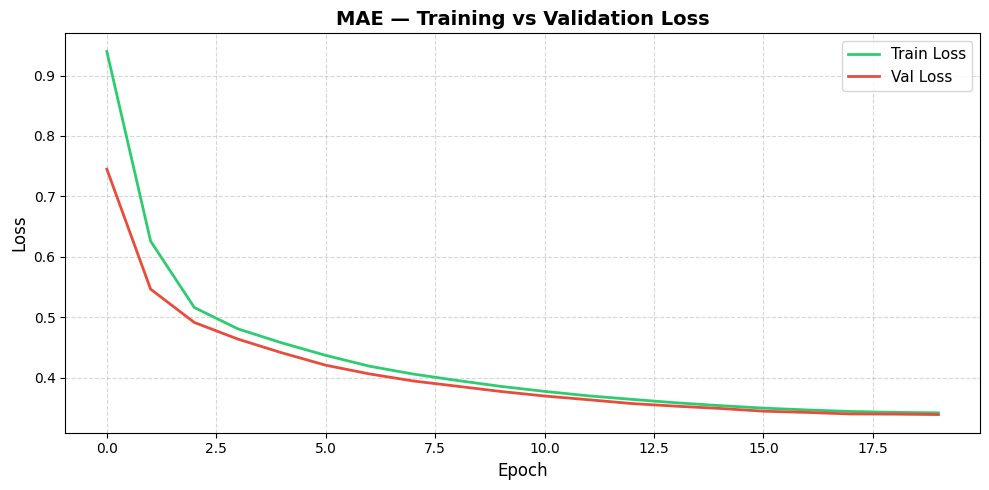

In [76]:

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss", color="#2ecc71", linewidth=2)
plt.plot(val_losses,   label="Val Loss",   color="#e74c3c", linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss",  fontsize=12)
plt.title("MAE — Training vs Validation Loss", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Sample     PSNR       SSIM      
1          16.71      0.3432
2          13.78      0.2237
3          16.72      0.2675
4          19.20      0.5170
5          14.05      0.2125
---------------------------------------------
Average    16.09      0.3128


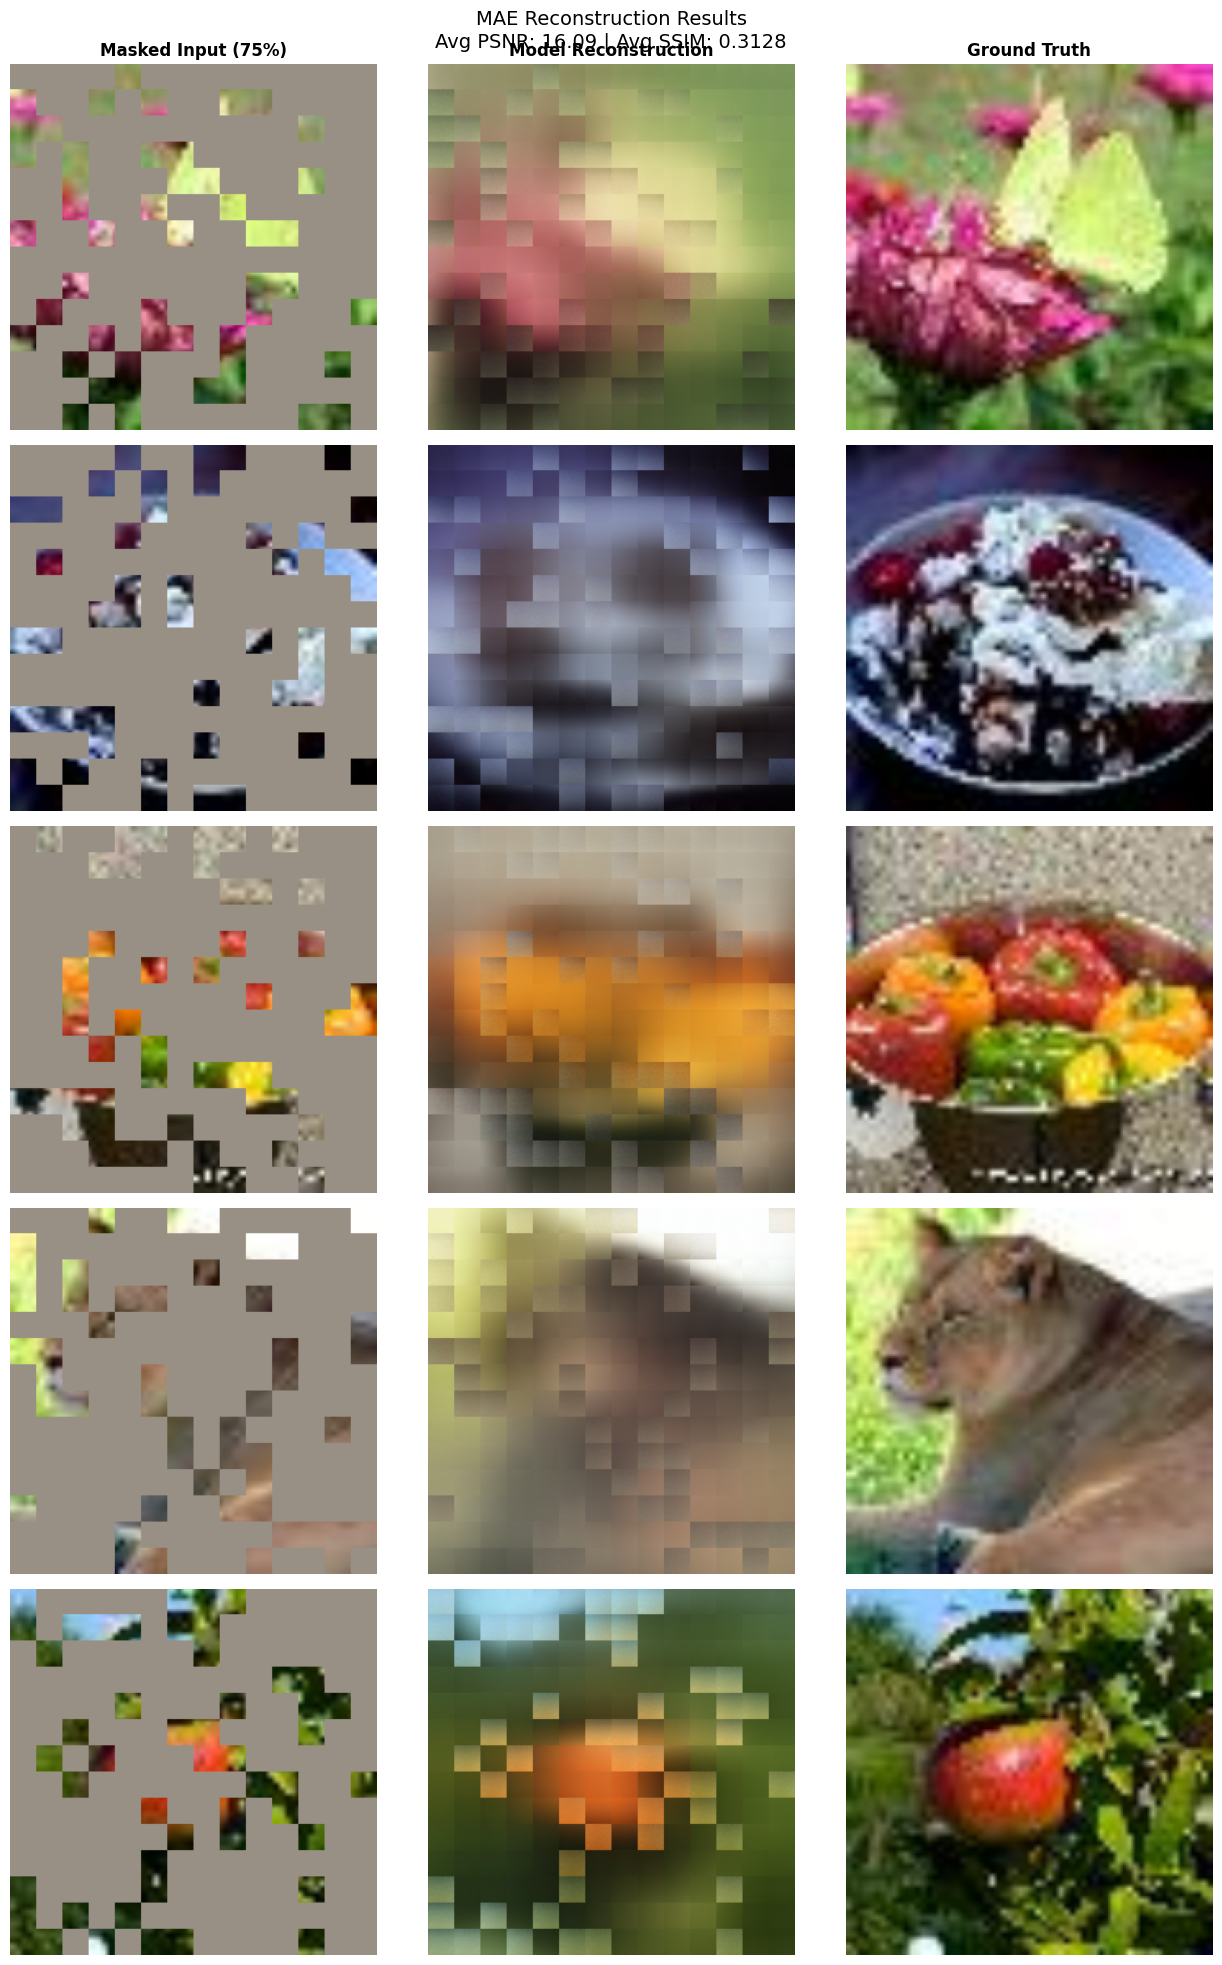

In [92]:
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import random
from PIL import Image


def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor.cpu()*std + mean).clamp(0,1)


def build_masked_image(imgs, mask, patch_size=16):
 
    patches = patchify(imgs, patch_size)     

    masked_patches = patches.clone()

    for b in range(patches.shape[0]):
        masked_patches[b][mask[b]==1] = 0.5

    masked_imgs = unpatchify(masked_patches, patch_size, imgs.shape[-1])
    return masked_imgs



transform_viz = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    ),
])

TEST_DIR = os.path.join(DATA_DIR,"test")

all_imgs = [
    os.path.join(r,f)
    for r,_,files in os.walk(TEST_DIR)
    for f in files if f.lower().endswith((".jpeg",".jpg",".png"))
]

random.seed()
chosen = random.sample(all_imgs,5)

images_batch = torch.stack([
    transform_viz(Image.open(p).convert("RGB"))
    for p in chosen
]).to(device)



viz_model = MAE().to(device)
viz_model.load_state_dict(torch.load("/kaggle/working/best_mae_model.pth",map_location=device))
viz_model.eval()

with torch.no_grad():
    recon_patches, mask = viz_model(images_batch)

recon_images = unpatchify(recon_patches,16,224)

masked_images = build_masked_image(
    images_batch.cpu(),
    mask.cpu(),
    patch_size=16
)

psnr_scores=[]
ssim_scores=[]

for i in range(5):

    orig_np = denormalize(images_batch[i]).permute(1,2,0).numpy()
    recon_np = denormalize(recon_images[i]).permute(1,2,0).numpy()

    psnr_scores.append(
        psnr_metric(orig_np,recon_np,data_range=1.0)
    )

    ssim_scores.append(
        ssim_metric(orig_np,recon_np,data_range=1.0,channel_axis=2)
    )

avg_psnr=sum(psnr_scores)/5
avg_ssim=sum(ssim_scores)/5


fig, axes = plt.subplots(5,3,figsize=(13,20))

titles = [
    "Masked Input (75%)",
    "Model Reconstruction",
    "Ground Truth"
]

for col,title in enumerate(titles):
    axes[0,col].set_title(title,fontweight="bold")


for row in range(5):

    panels=[
        denormalize(masked_images[row]).permute(1,2,0).numpy(),
        denormalize(recon_images[row]).permute(1,2,0).numpy(),
        denormalize(images_batch[row]).permute(1,2,0).numpy(),
    ]

    for col,panel in enumerate(panels):
        axes[row,col].imshow(panel)
        axes[row,col].axis("off")

    axes[row,2].set_ylabel(
        f"PSNR: {psnr_scores[row]:.2f}\nSSIM: {ssim_scores[row]:.4f}",
        rotation=0,
        labelpad=80,
        va="center"
    )


print("="*45)
print(f"{'Sample':<10} {'PSNR':<10} {'SSIM':<10}")
print("="*45)

for i in range(5):
    print(f"{i+1:<10} {psnr_scores[i]:<10.2f} {ssim_scores[i]:.4f}")

print("-"*45)
print(f"{'Average':<10} {avg_psnr:<10.2f} {avg_ssim:.4f}")
print("="*45)

plt.suptitle(
    f"MAE Reconstruction Results\nAvg PSNR: {avg_psnr:.2f} | Avg SSIM: {avg_ssim:.4f}",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/mae_reconstructions.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()